In [1]:
# Netflix Stock Price Forecasting Using ARIMA

In [2]:
#import library

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('/content/stock.csv')

In [4]:
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900
...,...,...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200


In [5]:
df.head(10)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900
5,2018-02-12,252.139999,259.149994,249.000000,257.950012,257.950012,8534900
6,2018-02-13,257.290009,261.410004,254.699997,258.269989,258.269989,6855200
7,2018-02-14,260.470001,269.880005,260.329987,266.000000,266.000000,10972000
8,2018-02-15,270.029999,280.500000,267.630005,280.269989,280.269989,10759700
9,2018-02-16,278.730011,281.959991,275.690002,278.519989,278.519989,8312400


In [6]:
df.tail(10)

,Date,Open,High,Low,Close,Adj Close,Volume
999,2022-01-24,383.910004,387.260010,351.459991,387.149994,387.149994,32346000
1000,2022-01-25,379.140015,387.709991,365.130005,366.420013,366.420013,15145800
1001,2022-01-26,378.269989,382.660004,356.619995,359.700012,359.700012,12684000
1002,2022-01-27,382.059998,394.799988,378.100006,386.700012,386.700012,24324700
1003,2022-01-28,386.760010,387.000000,372.079987,384.359985,384.359985,11966600
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200
1008,2022-02-04,407.309998,412.769989,396.640015,410.170013,410.170013,7782400


In [7]:
#This dataset contains the stock price values of Netflix from 2018 to 2022.
#open and close represent the starting and ending prices of the stock for  given date
#High and Low indicate the maximum and minimum prices of the stock during the day.
#Volume represents thenumber of shares traded on that day.


#Weekend and holiday Considerations: The stock market is closed on weekends and public holidays.
#Target ---->Adj close (actual closed on that day).

In [8]:
#We are going  use the Netflix stock dataset , we will check whether the data is ready for forecasting or not.

In [9]:
# drop unnessary columns
df=df.drop(['Open','High','Low','Close','Volume'],axis=1)
df

,Date,Adj Close
0,2018-02-05,254.259995
1,2018-02-06,265.720001
2,2018-02-07,264.559998
3,2018-02-08,250.100006
4,2018-02-09,249.470001
...,...,...
1004,2022-01-31,427.140015
1005,2022-02-01,457.130005
1006,2022-02-02,429.480011
1007,2022-02-03,405.600006


In [10]:
# check nullvalue
df.isnull().sum()

,0
Date,0
Adj Close,0


In [11]:
#check duplicate values
df.duplicated().sum()

np.int64(0)

In [12]:
# check col infrmation
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1009 non-null   object 
 1   Adj Close  1009 non-null   float64
dtypes: float64(1), object(1)
memory usage: 15.9+ KB


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1009 non-null   object 
 1   Adj Close  1009 non-null   float64
dtypes: float64(1), object(1)
memory usage: 15.9+ KB


In [14]:
#change date col in date type
df.Date =pd.to_datetime(df.Date)
df.head()

,Date,Adj Close
0,2018-02-05,254.259995
1,2018-02-06,265.720001
2,2018-02-07,264.559998
3,2018-02-08,250.100006
4,2018-02-09,249.470001


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1009 non-null   datetime64[ns]
 1   Adj Close  1009 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 15.9 KB


In [16]:
#now change date into index because we se arima model thatis time series model
df.set_index(['Date'],inplace=True)
df.head()

,Adj Close
Date,
2018-02-05,254.259995
2018-02-06,265.720001
2018-02-07,264.559998
2018-02-08,250.100006
2018-02-09,249.470001


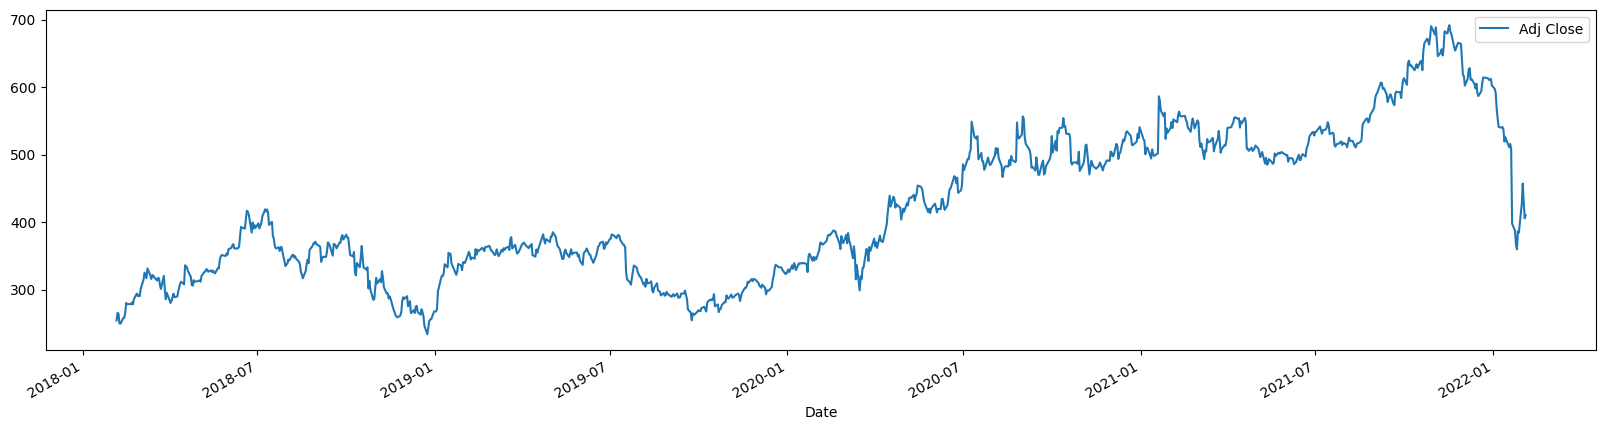

In [17]:
#reprenst data in lineplot
df.plot(figsize=(20,5))
plt.show()

In [18]:
#so after looking the data we see that that is not stationary
#So we do ADF-Agumented Dickey Fuller Test to check whether data is stationary or not.

In [19]:
#Import ADF
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Adj Close'])


if result[1]>0.05:
  print("Not stationary")
else:
  print("stationary")

Not stationary


In [20]:
df

,Adj Close
Date,
2018-02-05,254.259995
2018-02-06,265.720001
2018-02-07,264.559998
2018-02-08,250.100006
2018-02-09,249.470001
...,...
2022-01-31,427.140015
2022-02-01,457.130005
2022-02-02,429.480011


In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose

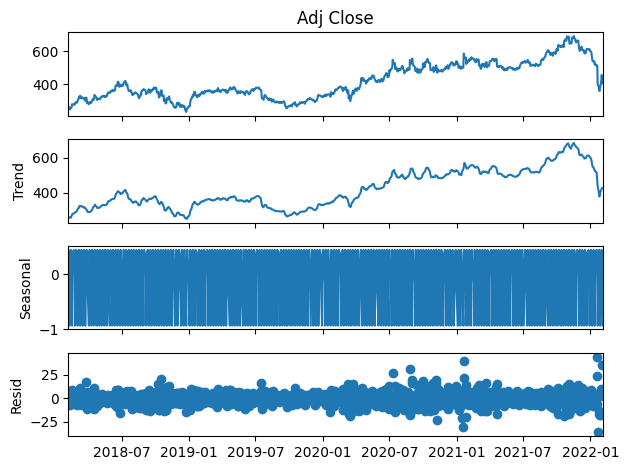

In [22]:
decomp=seasonal_decompose(df['Adj Close'],period=5)

#The seasonal pattern repeats for evry 5 observations
decomp.plot()
plt.show()

In [23]:
# differnce fro making data stationary
diff1=df-df.shift(1)
diff1

,Adj Close
Date,
2018-02-05,NaN
2018-02-06,11.460006
2018-02-07,-1.160003
2018-02-08,-14.459992
2018-02-09,-0.630005
...,...
2022-01-31,42.780030
2022-02-01,29.989990
2022-02-02,-27.649994


In [24]:
diff1.dropna(inplace=True)

In [25]:
diff1

,Adj Close
Date,
2018-02-06,11.460006
2018-02-07,-1.160003
2018-02-08,-14.459992
2018-02-09,-0.630005
2018-02-12,8.480011
...,...
2022-01-31,42.780030
2022-02-01,29.989990
2022-02-02,-27.649994


In [26]:
# test again to check data is stationary or not

In [27]:
result =adfuller(diff1['Adj Close'])
print("p value",result[1])

p value 1.5304022754298515e-26


In [28]:
if result[1]>0.05:
  print("Not stationary")
else:
  print("stationary")

stationary


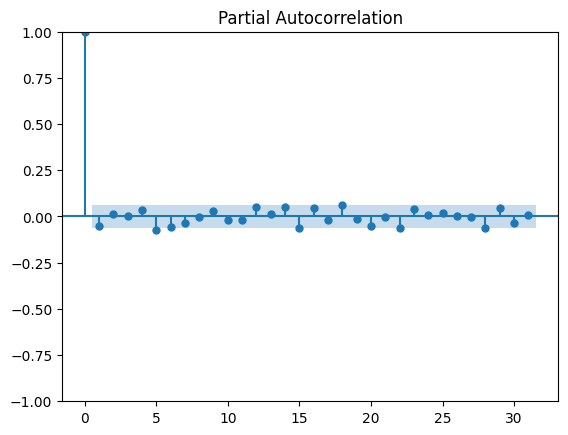

In [29]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(diff1)
plt.show()



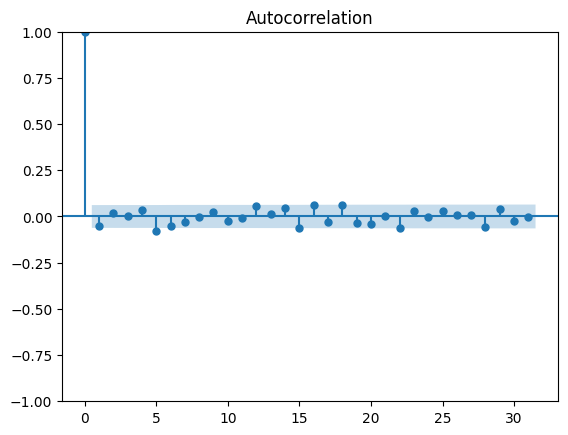

In [30]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(diff1)
plt.show()



In [31]:
# Train-test split: last 30 days for testing
train = df['Adj Close'][:-30]
test = df['Adj Close'][-30:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 979
Test size: 30


In [32]:
# model comparsion
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

models = [(0,1,0),(0,1,1),(1,1,0),(1,1,1),(1,1,2),(2,1,1),(2,1,2),(3,1,1)]

comp = []

for order in models:
    model = ARIMA(train,order=order)
    result = model.fit()
    forecast = result.forecast(steps=len(test))

    mae = mean_absolute_error(test,forecast)
    rmse = np.sqrt(mean_squared_error(test,forecast))

    comp.append([order,mae,rmse])

comp_df = pd.DataFrame(comp,columns=['ARIMA','MAE','RMSE'])



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

In [33]:
comp_df

,ARIMA,MAE,RMSE
0,"(0, 1, 0)",110.158654,139.756173
1,"(0, 1, 1)",109.235265,138.986100
2,"(1, 1, 0)",109.403462,139.125422
3,"(1, 1, 1)",109.344928,139.076876
4,"(1, 1, 2)",109.331102,139.065418
5,"(2, 1, 1)",109.349443,139.080607
6,"(2, 1, 2)",110.234438,139.837143
7,"(3, 1, 1)",108.872150,138.676075


In [34]:
# Best model

best_model = comp_df.sort_values('RMSE').iloc[0]

print("Best Model:",best_model['ARIMA'])
print("MAE:",best_model['MAE'])
print("RMSE:",best_model['RMSE'])

Best Model: (3, 1, 1)
MAE: 108.87214994818369
RMSE: 138.676074667325


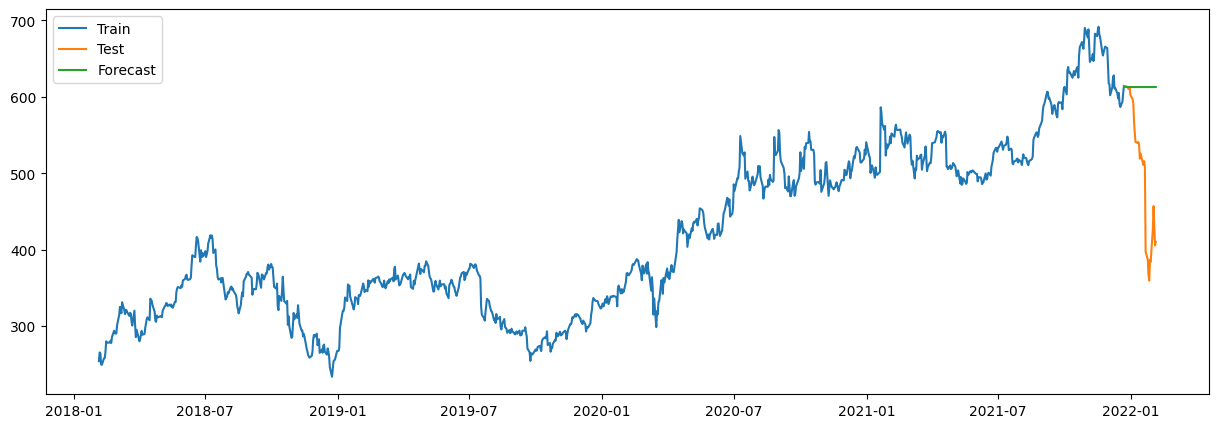

In [35]:
plt.figure(figsize=(15,5))
plt.plot(train.index,train,label='Train')
plt.plot(test.index,test,label='Test')
plt.plot(test.index,forecast,label='Forecast')
plt.legend()
plt.show()


**Final Interpretation**

I used the ARIMA model to predict Netflix's adjusted closing price.

First, I checked the data and found that it was not stationary. So, I used first-order differencing to make the data stationary. After differencing, the ADF test showed that the data had become stationary.

I then compared different ARIMA models using MAE and RMSE. The model with the lowest RMSE was selected as the best model.

The final model had an MAE of about 109.35 and an RMSE of about 139.08. This means that the model's predictions were not very close to the actual Netflix stock prices.

So, the ARIMA model was able to learn some patterns from the data, but it was not accurate enough for reliable stock-price prediction. This is because stock prices can change due to many outside factors, which are not included in my model.

### **Conclusion**

ARIMA is a good model for learning and understanding time-series forecasting. However, for better stock-price predictions, I can try other models such as SARIMAX and Machine Learning models. I can also include more information, such as market trends, trading volume, and other stock-related features.
